
## Fase 2 – Organización y Diseño  
### Paso 1: Transformación de la base de datos a nivel cliente

En este paso se utiliza la base de datos previamente depurada en la Fase 1, el objetivo es transformar la base transaccional en una base a nivel cliente, donde cada fila represente un cliente único y resuma su comportamiento de compra.

Para ello se construyen variables como recencia, frecuencia, gasto total, compra mínima, compra promedio y país asociado al cliente, esta estructura permitirá utilizar posteriormente el dataset en técnicas de segmentación y modelos supervisados.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Carga del conjunto de datos

Se carga la base de datos, posteriormente se replican los pasos de limpieza realizados en la Fase 1 para asegurar consistencia en el análisis.

In [3]:
path = "Appendix 1 - Database.csv"

df = pd.read_csv(path, encoding="latin1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom


## Preparación y limpieza de los datos

Se aplican los siguientes pasos de limpieza:

- Conversión de la fecha de factura al formato datetime.
- Eliminación de registros con valores faltantes en variables críticas.
- Eliminación de registros con cantidades o precios no positivos.
- Cálculo del valor total de cada línea de compra.

In [4]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

df_clean = df.dropna(subset=["InvoiceNo", "Quantity", "UnitPrice"]).copy()

df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]

df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34


## Consolidación de la información a nivel factura

Para simplificar la estructura del dataset, las transacciones se agregan a nivel de factura, esto permite calcular el valor total asociado a cada compra realizada por un cliente.

In [5]:
invoice_df = (
    df_clean.groupby("InvoiceNo", as_index=False)
    .agg({
        "InvoiceDate": "max",
        "CustomerID": "first",
        "Country": lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0],
        "TotalPrice": "sum"
    })
    .rename(columns={"TotalPrice": "InvoiceTotal"})
)

invoice_df.head()

,InvoiceNo,InvoiceDate,CustomerID,Country,InvoiceTotal
0,536365,2010-12-01 08:26:00,"17,850.00",United Kingdom,139.12
1,536366,2010-12-01 08:28:00,"17,850.00",United Kingdom,22.20
2,536367,2010-12-01 08:34:00,"13,047.00",United Kingdom,278.73
3,536368,2010-12-01 08:34:00,"13,047.00",United Kingdom,70.05
4,536369,2010-12-01 08:35:00,"13,047.00",United Kingdom,17.85


## Identificación y eliminación de valores extremos

Para reducir el impacto de facturas atípicas que puedan distorsionar el análisis, se aplica el método del rango intercuartílico (IQR) sobre el valor total de las facturas.

In [6]:
q1 = invoice_df["InvoiceTotal"].quantile(0.25)
q3 = invoice_df["InvoiceTotal"].quantile(0.75)

iqr = q3 - q1

lower = max(0, q1 - 1.5 * iqr)
upper = q3 + 1.5 * iqr

invoice_no_out = invoice_df[
    (invoice_df["InvoiceTotal"] >= lower) &
    (invoice_df["InvoiceTotal"] <= upper)
].copy()

invoice_no_out = invoice_no_out.dropna(subset=["CustomerID"]).copy()

print("Número de facturas después de eliminar outliers:", invoice_no_out.shape[0])
print("Número de clientes únicos:", invoice_no_out["CustomerID"].nunique())

Número de facturas después de eliminar outliers: 17239
Número de clientes únicos: 4245


## Construcción del dataset a nivel cliente

El siguiente paso consiste en transformar la base de datos para que cada fila represente un cliente único.

Las variables construidas son:

- Fecha de última compra
- Recencia (días desde la última compra)
- Frecuencia de compra
- Gasto total acumulado
- País asociado al cliente
- Compra mínima
- Compra promedio

In [7]:
analysis_date = invoice_no_out["InvoiceDate"].max()

customer_level = (
    invoice_no_out.groupby("CustomerID", as_index=False)
    .agg(
        LastPurchaseDate=("InvoiceDate", "max"),
        Frequency=("InvoiceNo", "nunique"),
        TotalSpent=("InvoiceTotal", "sum"),
        Country=("Country", lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]),
        MinPurchase=("InvoiceTotal", "min"),
        AvgPurchase=("InvoiceTotal", "mean")
    )
)

customer_level["Recency"] = (analysis_date - customer_level["LastPurchaseDate"]).dt.days

customer_level = customer_level[
    ["CustomerID","LastPurchaseDate","Recency","Frequency","TotalSpent","Country","MinPurchase","AvgPurchase"]
]

customer_level.head()

,CustomerID,LastPurchaseDate,Recency,Frequency,TotalSpent,Country,MinPurchase,AvgPurchase
0,"12,347.00",2011-12-07 15:52:00,1,6,"3,015.68",Iceland,224.82,502.61
1,"12,348.00",2011-09-25 13:13:00,74,4,"1,797.24",Finland,227.44,449.31
2,"12,350.00",2011-02-02 16:01:00,309,1,334.40,Norway,334.40,334.40
3,"12,352.00",2011-11-03 14:37:00,35,8,"2,506.04",Norway,120.33,313.25
4,"12,353.00",2011-05-19 17:47:00,203,1,89.00,Bahrain,89.00,89.00


##  Validación de la estructura del dataset

Se verifica la dimensión del dataset y la presencia de valores faltantes para asegurar la consistencia de la base a nivel cliente.

In [8]:
print("Dimensión del dataset:", customer_level.shape)

print("\nValores faltantes por variable:")
print(customer_level.isna().sum())

Dimensión del dataset: (4245, 8)

Valores faltantes por variable:
CustomerID          0
LastPurchaseDate    0
Recency             0
Frequency           0
TotalSpent          0
Country             0
MinPurchase         0
AvgPurchase         0
dtype: int64


## Análisis descriptivo de variables numéricas

Se calculan estadísticas descriptivas de las principales variables numéricas para comprender la distribución del comportamiento de compra de los clientes.

In [9]:
customer_level[["Recency","Frequency","TotalSpent","MinPurchase","AvgPurchase"]].describe()

,Recency,Frequency,TotalSpent,MinPurchase,AvgPurchase
count,"4,245.00","4,245.00","4,245.00","4,245.00","4,245.00"
mean,93.13,4.06,"1,268.80",211.39,303.36
std,100.68,6.97,"2,419.74",173.63,170.56
min,0.00,1.00,2.90,0.38,2.90
25%,17.00,1.00,300.36,90.48,174.40
50%,50.00,2.00,628.38,165.05,278.53
75%,148.00,4.00,"1,401.49",304.90,392.06
max,373.00,205.00,"80,456.79","1,002.31","1,002.31"


## Distribución de clientes por país

Se analiza la distribución de clientes según el país de origen de las compras para comprender la composición geográfica del dataset.

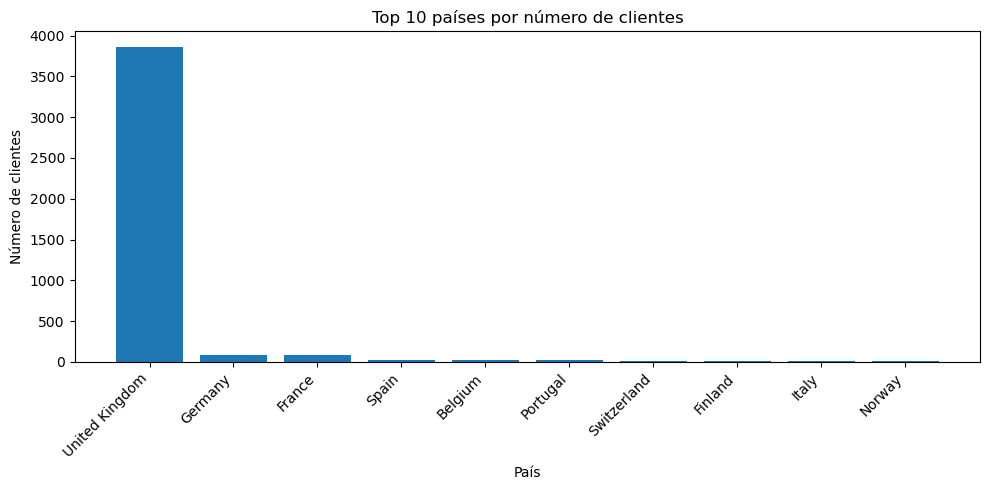

In [10]:
top_countries = customer_level["Country"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(top_countries.index, top_countries.values)

plt.xticks(rotation=45, ha="right")
plt.xlabel("País")
plt.ylabel("Número de clientes")
plt.title("Top 10 países por número de clientes")

plt.tight_layout()
plt.show()

## Interpretación del análisis exploratorio

El análisis exploratorio evidencia que el comportamiento de los clientes es heterogéneo, algunos clientes presentan actividad de compra reciente, mientras que otros muestran periodos más largos sin transacciones, asimismo, la distribución de la frecuencia de compra y del gasto total sugiere que un grupo reducido de clientes concentra una parte importante del valor económico generado.

Estos resultados justifican la aplicación de técnicas de segmentación en los siguientes pasos del análisis, con el fin de identificar grupos de clientes con patrones de comportamiento similares.

# Paso 2. Segmentación de clientes mediante K-means

En este paso se aplica el algoritmo K-means para identificar grupos de clientes con comportamientos de compra similares, para esto se utilizan las variables Recency, Frequency y TotalSpent.

In [11]:
features = customer_level[["Recency","Frequency","TotalSpent"]]

features.head()

,Recency,Frequency,TotalSpent
0,1,6,"3,015.68"
1,74,4,"1,797.24"
2,309,1,334.40
3,35,8,"2,506.04"
4,203,1,89.00


## Escalamiento de variables

Las variables se escalan para evitar que aquellas con mayor magnitud influyan más en el cálculo de distancias del algoritmo.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[-0.91524081,  0.27830561,  0.72201496],
       [-0.19006439, -0.00875728,  0.2184138 ],
       [ 2.14440763, -0.43935162, -0.38620188],
       [-0.57748741,  0.56536851,  0.51137242],
       [ 1.09141174, -0.43935162, -0.48762971]])

## Determinación del número de clústeres (método del codo)

In [13]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(1,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

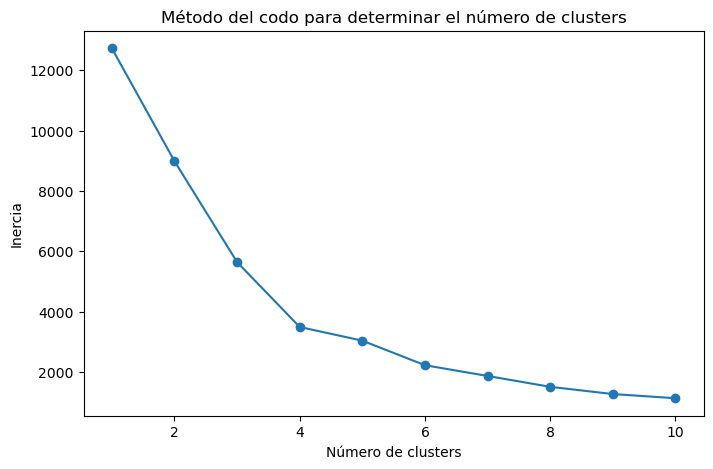

In [14]:
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker="o")

plt.xlabel("Número de clusters")
plt.ylabel("Inercia")

plt.title("Método del codo para determinar el número de clusters")

plt.show()

## Aplicación del algoritmo K-means

In [15]:
kmeans = KMeans(n_clusters=4, random_state=42)

customer_level["Cluster"] = kmeans.fit_predict(scaled_features)

customer_level.head()

,CustomerID,LastPurchaseDate,Recency,Frequency,TotalSpent,Country,MinPurchase,AvgPurchase,Cluster
0,"12,347.00",2011-12-07 15:52:00,1,6,"3,015.68",Iceland,224.82,502.61,0
1,"12,348.00",2011-09-25 13:13:00,74,4,"1,797.24",Finland,227.44,449.31,0
2,"12,350.00",2011-02-02 16:01:00,309,1,334.40,Norway,334.40,334.40,1
3,"12,352.00",2011-11-03 14:37:00,35,8,"2,506.04",Norway,120.33,313.25,0
4,"12,353.00",2011-05-19 17:47:00,203,1,89.00,Bahrain,89.00,89.00,1


# Paso 3. Visualización e interpretación de los clústeres

Una vez aplicado el algoritmo K-means, se procede a analizar los grupos de clientes identificados por el modelo, para ello se visualiza la distribución de los clientes según su gasto total y el clúster asignado, lo que permite observar cómo se diferencian los segmentos obtenidos.

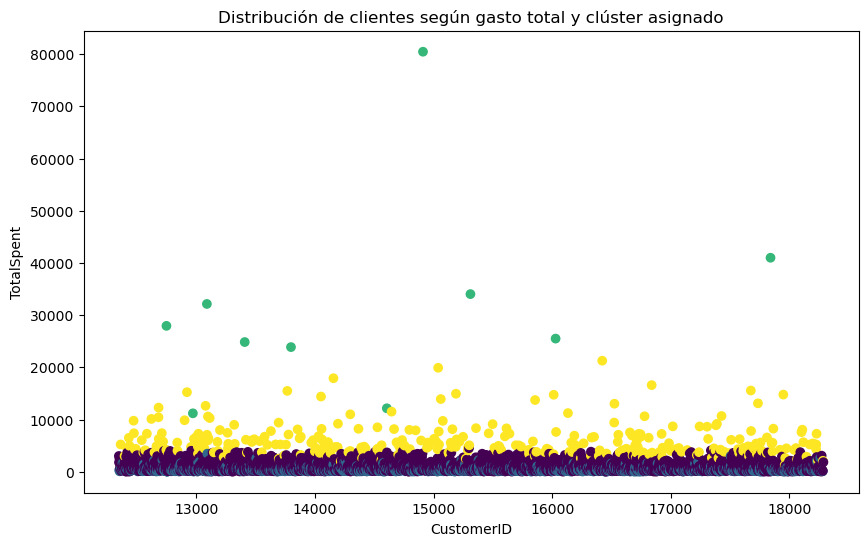

In [16]:
plt.figure(figsize=(10,6))

plt.scatter(
    customer_level["CustomerID"],
    customer_level["TotalSpent"],
    c=customer_level["Cluster"]
)

plt.xlabel("CustomerID")
plt.ylabel("TotalSpent")
plt.title("Distribución de clientes según gasto total y clúster asignado")

plt.show()

## Estadísticas de los clústeres

Para comprender mejor las diferencias entre los grupos identificados por el algoritmo, se calculan estadísticas descriptivas de las variables utilizadas en el clustering para cada clúster.

In [17]:
cluster_summary = customer_level.groupby("Cluster")[["Recency","Frequency","TotalSpent"]].describe()

cluster_summary

Recency                                                 Frequency                                       \
           count   mean   std    min    25%    50%    75%    max     count  mean   std   min   25%   50%    75%   
Cluster                                                                                                           
0       2,853.00  43.87 36.39   0.00  15.00  33.00  66.00 155.00  2,853.00  3.31  2.38  1.00  1.00  3.00   4.00   
1       1,077.00 246.74 66.01 141.00 189.00 242.00 296.00 373.00  1,077.00  1.55  1.06  1.00  1.00  1.00   2.00   
2          10.00   4.90 11.71   0.00   0.00   1.00   2.75  38.00     10.00 98.50 51.21 49.00 63.50 83.00 116.25   
3         305.00  14.41 28.46   0.00   2.00   7.00  17.00 371.00    305.00 16.86  7.60  7.00 12.00 14.00  20.00   

               TotalSpent                                                                        
           max      count      mean       std       min       25%       50%       75%       max  
Cluster                                                                                          
0        14.00   2,853.00    992.95    828.15      4.95    357.77    725.11  1,400.34  4,507.01  
1        12.00   1,077.00    413.65    382.53      2.90    167.50    307.90    518.67  3,461.90  
2       205.00      10.00 31,313.50 19,524.87 11,189.91 24,117.70 26,725.78 33,556.57 80,456.79  
3        55.00     305.00  5,883.64  3,022.81  1,296.44  3,995.23  5,010.28  6,776.56 21,269.47

## Resumen de comportamiento por clúster

Para facilitar la interpretación de los segmentos, también se calculan las medias de las variables principales por clúster.

In [18]:
cluster_means = customer_level.groupby("Cluster")[["Recency","Frequency","TotalSpent"]].mean()

cluster_means

,Recency,Frequency,TotalSpent
Cluster,,,
0,43.87,3.31,992.95
1,246.74,1.55,413.65
2,4.90,98.50,"31,313.50"
3,14.41,16.86,"5,883.64"


Los resultados permiten observar diferencias claras entre los grupos de clientes identificados por el modelo, algunos clústeres presentan mayores niveles de gasto y frecuencia de compra, mientras que otros muestran menor actividad o mayores valores de recencia.

# Paso 4. Correlación y clustering jerárquico de variables

En este paso se analiza la relación entre las variables numéricas del dataset a nivel cliente, para ello se calcula la matriz de correlación de Spearman y posteriormente se aplica un método de clustering jerárquico aglomerativo con el fin de identificar grupos de variables que presentan comportamientos similares.

## Selección de variables numéricas

In [32]:
numeric_vars = customer_level[[
    "Recency",
    "Frequency",
    "TotalSpent",
    "MinPurchase",
    "AvgPurchase"
]]

numeric_vars.head()

,Recency,Frequency,TotalSpent,MinPurchase,AvgPurchase
0,1,6,"3,015.68",224.82,502.61
1,74,4,"1,797.24",227.44,449.31
2,309,1,334.40,334.40,334.40
3,35,8,"2,506.04",120.33,313.25
4,203,1,89.00,89.00,89.00


## Matriz de correlación de Spearman

La correlación de Spearman permite evaluar relaciones monotónicas entre variables sin asumir necesariamente una relación lineal, este enfoque resulta adecuado para variables de comportamiento como las utilizadas en este análisis.

In [33]:
spearman_corr = numeric_vars.corr(method="spearman")

spearman_corr

,Recency,Frequency,TotalSpent,MinPurchase,AvgPurchase
Recency,1.00,-0.55,-0.49,0.21,-0.10
Frequency,-0.55,1.00,0.84,-0.46,0.11
TotalSpent,-0.49,0.84,1.00,-0.01,0.61
MinPurchase,0.21,-0.46,-0.01,1.00,0.64
AvgPurchase,-0.10,0.11,0.61,0.64,1.00


## Visualización de la matriz de correlación

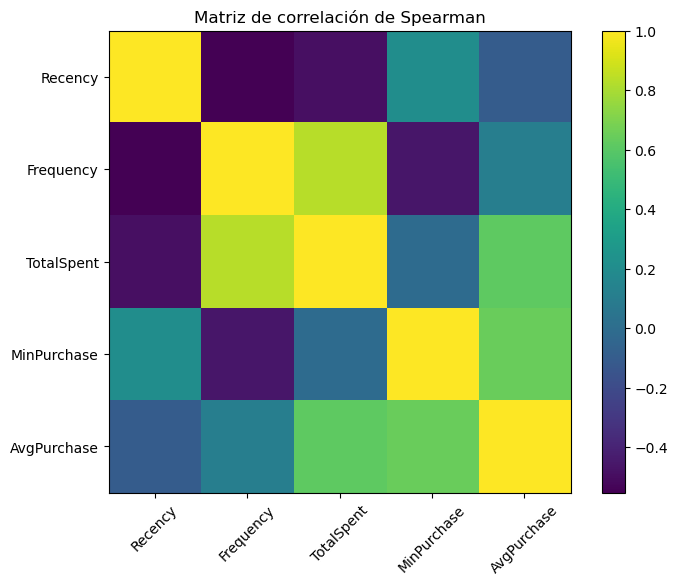

In [34]:
plt.figure(figsize=(8,6))

plt.imshow(spearman_corr)

plt.xticks(range(len(spearman_corr.columns)), spearman_corr.columns, rotation=45)
plt.yticks(range(len(spearman_corr.columns)), spearman_corr.columns)

plt.colorbar()

plt.title("Matriz de correlación de Spearman")

plt.show()

## Clustering jerárquico de variables

In [35]:
from scipy.cluster.hierarchy import linkage, dendrogram

In [36]:
linkage_matrix = linkage(spearman_corr, method="ward")

## Dendrograma de variables

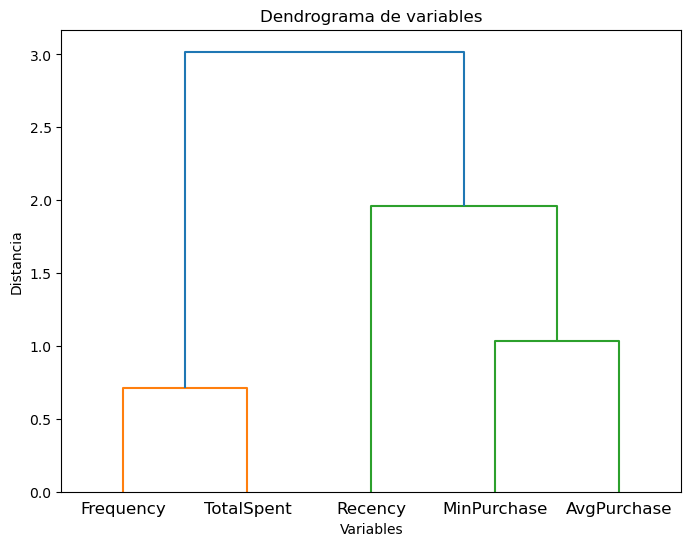

In [37]:
plt.figure(figsize=(8,6))

dendrogram(
    linkage_matrix,
    labels=spearman_corr.columns
)

plt.title("Dendrograma de variables")

plt.xlabel("Variables")
plt.ylabel("Distancia")

plt.show()

El dendrograma permite observar qué variables presentan comportamientos más similares dentro del conjunto de datos. Variables que aparecen unidas a menor distancia tienden a tener patrones de variación más parecidos, mientras que aquellas que se conectan a mayor distancia presentan comportamientos más independientes.

# Paso 5. Preparación de un modelo supervisado de churn en Python

En este paso se construye un modelo supervisado para predecir el churn de clientes, primero se transforma la variable categórica Country a formato numérico, luego se define la variable objetivo Churn a partir de la recencia del cliente y, finalmente, se entrenan y comparan dos modelos de clasificación: Regresión Logística y Máquina de Soporte Vectorial (SVM).

## 1. Preparación de variables para el modelado

Para el proceso de modelado se utilizarán variables relacionadas con el comportamiento de compra del cliente, además, la variable Country será transformada a una representación numérica adecuada para algoritmos de clasificación.

In [19]:
model_data = customer_level[[
    "Recency",
    "Frequency",
    "TotalSpent",
    "MinPurchase",
    "AvgPurchase",
    "Country"
]].copy()

model_data.head()

,Recency,Frequency,TotalSpent,MinPurchase,AvgPurchase,Country
0,1,6,"3,015.68",224.82,502.61,Iceland
1,74,4,"1,797.24",227.44,449.31,Finland
2,309,1,334.40,334.40,334.40,Norway
3,35,8,"2,506.04",120.33,313.25,Norway
4,203,1,89.00,89.00,89.00,Bahrain


## 2. Codificación de la variable Country

Dado que Country es una variable categórica, se transforma a formato numérico mediante codificación dummy, este procedimiento crea una columna binaria para cada país y permite incorporar esta información al modelo sin imponer un orden artificial entre categorías.

In [21]:
model_data_encoded = pd.get_dummies(model_data, columns=["Country"], drop_first=True)

model_data_encoded.head()

,Recency,Frequency,TotalSpent,MinPurchase,AvgPurchase,Country_Austria,Country_Bahrain,Country_Belgium,Country_Canada,Country_Channel Islands,Country_Cyprus,Country_Czech Republic,Country_Denmark,Country_EIRE,Country_European Community,Country_Finland,Country_France,Country_Germany,Country_Greece,Country_Iceland,Country_Israel,Country_Italy,Country_Japan,Country_Lithuania,Country_Malta,Country_Netherlands,Country_Norway,Country_Poland,Country_Portugal,Country_RSA,Country_Saudi Arabia,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified
0,1,6,"3,015.68",224.82,502.61,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,74,4,"1,797.24",227.44,449.31,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,309,1,334.40,334.40,334.40,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
3,35,8,"2,506.04",120.33,313.25,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
4,203,1,89.00,89.00,89.00,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## 3. Definición de la variable objetivo Churn

Se define la variable Churn a partir de la recencia del cliente, en este caso, se considera churn a todo cliente que lleve más de 90 días sin realizar compras, de esta forma:

- Churn = 1: cliente sin compras en más de 90 días
- Churn = 0: cliente con actividad reciente

In [22]:
model_data_encoded["Churn"] = (model_data_encoded["Recency"] > 90).astype(int)

model_data_encoded["Churn"].value_counts()

Churn
0    2791
1    1454
Name: count, dtype: int64

## 4. Separación entre variables predictoras y variable objetivo

In [41]:
X = model_data_encoded.drop(columns=["Churn"])
y = model_data_encoded["Churn"]

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

Dimensión de X: (4245, 39)
Dimensión de y: (4245,)


## 5. División en conjuntos de entrenamiento y prueba

El dataset se divide en dos conjuntos: entrenamiento y prueba. Se utiliza una partición 80/20 y estratificación sobre la variable objetivo para conservar la proporción de clases en ambos conjuntos.

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3396, 39)
X_test: (849, 39)
y_train: (3396,)
y_test: (849,)


## 6. Escalamiento de variables

Se aplica escalamiento a las variables predictoras antes de entrenar los modelos, ya que tanto la Regresión Logística como SVM se benefician de trabajar con variables en escalas comparables.

In [44]:
from sklearn.preprocessing import StandardScaler

scaler_model = StandardScaler()

X_train_scaled = scaler_model.fit_transform(X_train)
X_test_scaled = scaler_model.transform(X_test)

## 7. Entrenamiento del modelo de Regresión Logística

In [45]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

## 8. Entrenamiento del modelo SVM

In [47]:
from sklearn.svm import SVC

svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

## 9. Evaluación de los modelos

Para comparar el desempeño de los modelos se calculan métricas de clasificación: accuracy, precision, recall, F1-score y ROC-AUC.

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

metrics_df = pd.DataFrame({
    "Modelo": ["Regresión Logística", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_svm)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_svm)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_svm)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_svm)
    ]
})

metrics_df

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regresión Logística,0.98,1.00,0.95,0.97,1.00
1,SVM,0.95,0.98,0.88,0.93,1.00


## 10. Matrices de confusión

In [49]:
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(y_test, y_pred_log)
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Matriz de confusión - Regresión Logística")
print(cm_log)

print("\nMatriz de confusión - SVM")
print(cm_svm)

Matriz de confusión - Regresión Logística
[[558   0]
 [ 15 276]]

Matriz de confusión - SVM
[[552   6]
 [ 35 256]]


## 11. Curvas ROC

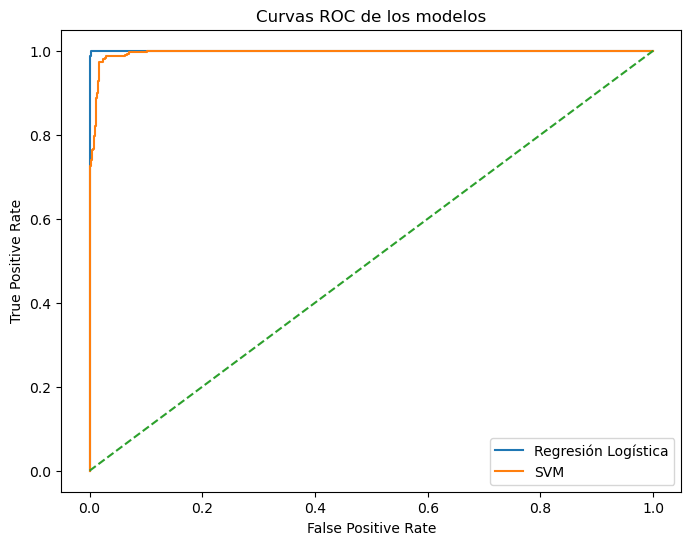

In [50]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label="Regresión Logística")
plt.plot(fpr_svm, tpr_svm, label="SVM")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC de los modelos")
plt.legend()

plt.show()